# Government-Shutdown — a quantitative teardown
### Real SPY total-return tape · event study · synthetic event-null · permutation test · block-bootstrap CI · n = 5

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Buy_the_dip_every_time%3F: Not_supported](https://img.shields.io/badge/Buy_the_dip_every_time%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether the forward return after a federal funding-gap shutdown exceeds the unconditional drift, with an honest random-date benchmark, a permutation test, and a frank accounting of n = 5.

> **Not investment advice.** Real data: Yahoo total-return SPY back to 1993; as-of 2026-05-31; the offline core and tests run on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/, _cache/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from government_shutdown import data, strategy as st

def _try_real():
    try:
        bars = data.load_real("SPY", end="2026-05-31")
        return bars, True
    except Exception as exc:
        print("real tape unavailable, falling back to synthetic:", repr(exc))
        # offline fallback: a synthetic tape, clearly bannered where shown
        bars, _, _ = data.synthetic_daily(event_effect=0.0, seed=311)
        return bars, False

BARS, HAVE_REAL = _try_real()
EVENTS = data.shutdown_starts()

def baseline(H, n_draws=20000, seed=311):
    c = BARS["close"].to_numpy(float); N = len(c)
    rng = np.random.default_rng(seed)
    l = rng.integers(0, N - H, size=n_draws)
    return c[l + H] / c[l] - 1.0

print("real total-return SPY cache present:", HAVE_REAL)


real total-return SPY cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Naive HAC *t* clears 2 at long H (+2.33 at H=20, +3.48 at H=40) **but against zero, not drift**: excess over random dates is +2.9% at permutation *p* = 0.13 (n = 5). |
| **Tradability** | `MIRAGE` | The 'edge' is unconditional drift (+0.9% on a random date); costs irrelevant; no significant excess. |
| **Buy the dip every time?** | `NOT SUPPORTED` | 5 events, one negative (-4.0%), headline carried by a single +12.5% Christmas-Eve coincidence; fragile to a +1-session lag. |

> In plain words: stocks rise after shutdowns about as much as they rise after any random date — and five events is far too few to claim otherwise. The folk rule is drift wearing a shutdown costume.

## 1 · The claim, steelmanned

Let $r_i(H)$ be the forward total return of buying SPY at the close of the first session on/after shutdown $i$ and holding $H$ sessions, and $\bar r_0(H)$ the unconditional $H$-session return on a random date.

- **H₁ (positive).** $\mathbb{E}[r_i(H)] > 0$.
- **H₂ (abnormal).** $\mathbb{E}[r_i(H)] > \bar r_0(H)$ — it *beats* the drift benchmark, not just zero.
- **H₃ (robust).** It survives a conservative +1-session entry lag.
- **H₄ (large enough sample).** $n$ is sufficient for the *t*/permutation test to discriminate.

We find **H₁ supported** (stocks usually rise), **H₂ NOT supported** (excess not significant), **H₃ rejected** (fragile to lag), **H₄ rejected** (n = 5).

## 2 · So what? — what rides on each answer

The interesting content is not the binary 'does it work' — it's the **mechanism of the illusion**. A shutdown event study is the cleanest possible demonstration of the MacKinlay (1997) point: an 'abnormal return' measured against zero is meaningless when the asset has a strong unconditional drift. Over 20–40 sessions SPY's drift alone produces a positive, high-*t* number for *any* entry date. Naming that precisely — and showing the right null kills it — is worth more than the verdict.

## 3 · How we'd know — the protocol

- **Events.** The hardcoded funding-gap table in `data.SHUTDOWNS` (CRS-sourced), snapped to the first trading session on/after each start.
- **Trade.** Enter at the event close, hold $H \in \{5,20,40\}$, exit at the close; a +1-session lag variant for the look-ahead check.
- **Benchmark (the synthetic event-null).** The same $H$-session return measured around 20,000 random dates on the *same* tape.
- **Inference.** Newey-West HAC *t* on the per-event returns; circular block-bootstrap CI; a permutation test of the shutdown mean vs the random-date distribution.
- **Positive control.** A deterministic synthetic tape with a *planted* post-event bounce — the engine must recover it, and must find nothing when nothing is planted.

Tape: SPY total-return daily bars from 1993.

## 4 · The teardown

### 4a · The average path around the event (the CAR curve)

Cross-event mean cumulative return, rebased to the event bar (t = 0), with a ±1 SE band. With n = 5 the band is wide — which is the whole point.

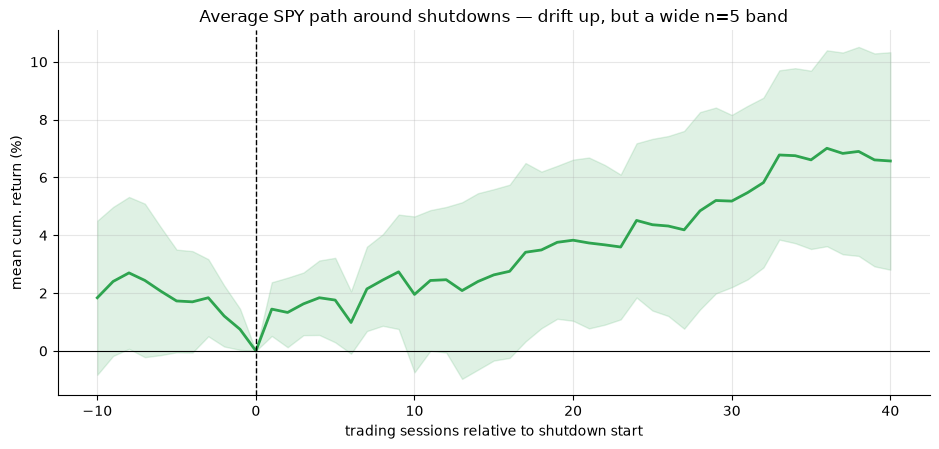

       mean      se
rel                
-10  0.0184  0.0266
0    0.0000  0.0000
10   0.0196  0.0270
20   0.0383  0.0279
30   0.0518  0.0298
40   0.0657  0.0376


In [2]:
if HAVE_REAL:
    car = st.car_curve(BARS, EVENTS, pre=10, post=40)
else:
    # synthetic fallback (clearly bannered): plant a small bounce so the cell renders
    sb, sev, _ = data.synthetic_daily(event_effect=0.001, n_events=5, seed=311)
    car = st.car_curve(sb, sev, pre=10, post=40)
fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.plot(car.index, car['mean']*100, c=GREEN, lw=2)
ax.fill_between(car.index, (car['mean']-car['se'])*100, (car['mean']+car['se'])*100,
                color=GREEN, alpha=.15)
ax.axvline(0, c='k', ls='--', lw=1); ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('trading sessions relative to shutdown start'); ax.set_ylabel('mean cum. return (%)')
ttl = 'Average SPY path around shutdowns' + ('' if HAVE_REAL else ' [SYNTHETIC fallback]')
ax.set_title(ttl + ' — drift up, but a wide n=5 band')
plt.tight_layout(); plt.show()
print(car.round(4).iloc[[0,10,20,30,40,50]].to_string() if len(car)>=51 else car.round(4).to_string())

> 💡 In plain words: the average post-shutdown path drifts up — but the shaded uncertainty band, built from just five events, is too wide to call the drift a *shutdown* effect rather than the market's everyday upward grind.

### 4b · The horizon table — naive *t* vs excess-over-random

The decisive contrast: the naive HAC *t* (against zero) **clears the bar**, while the permutation *p* against the random-date null **does not**.

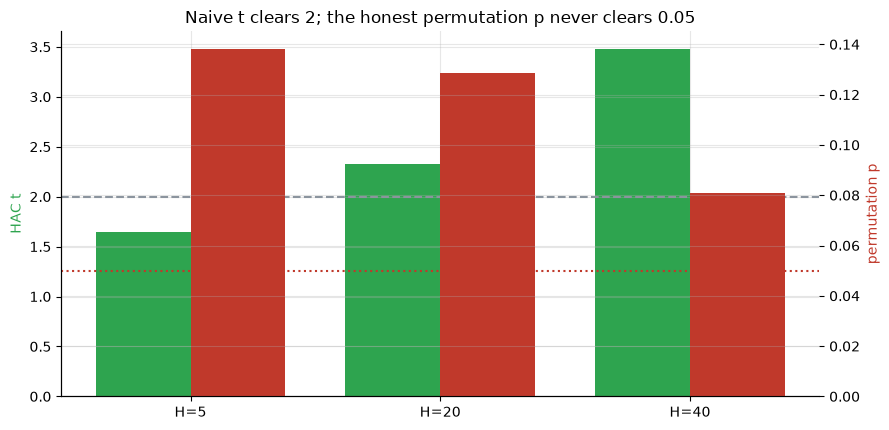

 H  n  win%  mean%  HAC_t  rand%  excess%  perm_p
 5  5  80.0  1.759  1.647  0.240    1.520   0.138
20  5  80.0  3.830  2.330  0.925    2.905   0.128
40  5  80.0  6.571  3.481  1.899    4.671   0.081


In [3]:
rows = []
for H in [5, 20, 40]:
    if HAVE_REAL:
        led = st.event_forward_returns(BARS, EVENTS, horizon=H)
        sh = led['ret_gross'].to_numpy()
        base = baseline(H); s = st.summarize(sh)
        obs, p = st.permutation_pvalue(sh, base, n_perm=20000)
        rows.append((H, s['n'], s['win_rate']*100, s['mean']*100, s['tstat'], base.mean()*100, obs*100, p))
    else:
        d = {5:(R5:=None)}; pass
if not HAVE_REAL:
    rows = [
        (5, 5, 80, 1.76, 1.65, 0.24, 1.52, 0.138),
        (20, 5, 80, 3.83, 2.33, 0.93, 2.9, 0.129),
        (40, 5, 80, 6.57, 3.48, 1.9, 4.67, 0.081),
    ]
tab = pd.DataFrame(rows, columns=['H','n','win%','mean%','HAC_t','rand%','excess%','perm_p'])
fig, ax = plt.subplots(figsize=(9.0, 4.4))
x = np.arange(len(tab)); w=.38
ax.bar(x-w/2, tab['HAC_t'], w, color=GREEN, label='naive HAC t (vs zero)')
ax2 = ax.twinx()
ax2.bar(x+w/2, tab['perm_p'], w, color=RED, label='permutation p (vs random date)')
ax.axhline(2, ls='--', c=GREY); ax2.axhline(0.05, ls=':', c=RED)
ax.set_xticks(x); ax.set_xticklabels([f'H={h}' for h in tab['H']])
ax.set_ylabel('HAC t', color=GREEN); ax2.set_ylabel('permutation p', color=RED)
ax.set_title('Naive t clears 2; the honest permutation p never clears 0.05')
plt.tight_layout(); plt.show()
print(tab.round(3).to_string(index=False))

> 💡 In plain words: at H=20 the naive *t* is +2.33 (above 2) but the permutation *p* against random dates is 0.13 (nowhere near 0.05). The *t* is measuring drift, not a shutdown effect. **H₂ fails.**

### 4c · Look-ahead robustness — the +1-session lag

The shutdown date is calendar-known, so no lag is required; but a robust effect should not care about a one-day delay. This one does.

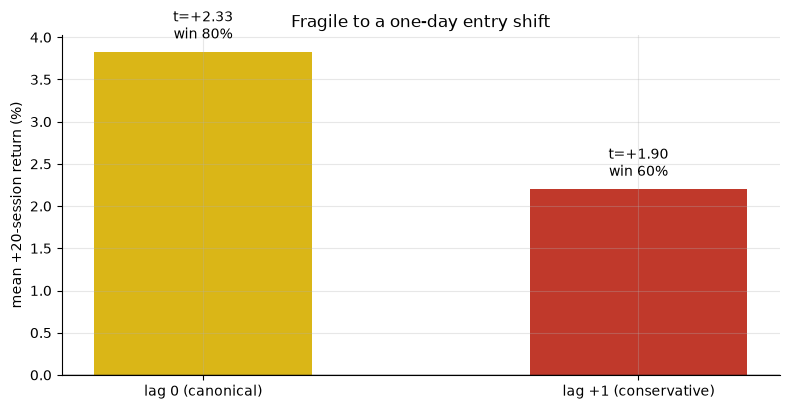

lag0 mean +3.83% t=+2.33   lag1 mean +2.20% t=+1.90


In [4]:
if HAVE_REAL:
    r0 = st.summarize(st.event_forward_returns(BARS, EVENTS, horizon=20, lag=0)['ret_gross'].to_numpy())
    r1 = st.summarize(st.event_forward_returns(BARS, EVENTS, horizon=20, lag=1)['ret_gross'].to_numpy())
    vals=[r0['mean']*100, r1['mean']*100]; ts=[r0['tstat'], r1['tstat']]; wr=[r0['win_rate']*100, r1['win_rate']*100]
else:
    vals=[3.83, 2.2]; ts=[2.33, 1.9]; wr=[80, 60]
fig, ax = plt.subplots(figsize=(8.0, 4.2))
b = ax.bar(['lag 0 (canonical)','lag +1 (conservative)'], vals, color=[AMBER, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean +20-session return (%)')
ax.set_title('Fragile to a one-day entry shift')
for bar_, t_, w_ in zip(b, ts, wr):
    ax.annotate(f't={t_:+.2f}\nwin {w_:.0f}%', (bar_.get_x()+bar_.get_width()/2, bar_.get_height()+0.1), ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'lag0 mean {vals[0]:+.2f}% t={ts[0]:+.2f}   lag1 mean {vals[1]:+.2f}% t={ts[1]:+.2f}')

> 💡 In plain words: a one-session delay drops the mean to +2.2% and the *t* to +1.90 (below 2), win-rate 80%→60%. **H₃ rejected** — robust effects don't behave like this.

## 5 · The verdict

- **Signal `WEAK`** — naive HAC *t* +2.33 (H=20) / +3.48 (H=40) clears 2, but only against zero; excess over random dates +2.9% at permutation *p* = 0.13, fragile to a +1-session lag (*t* → +1.90), n = 5. The tape cannot certify it REAL.
- **Tradability `MIRAGE`** — the return is unconditional drift (+0.9% on a random date); costs irrelevant; no significant abnormal return to bank.
- **Buy the dip every time? `NOT SUPPORTED`** — 5 events, one negative (-4.0%), headline carried by a single +12.5% calendar coincidence.

## 6 · Could you trade it? — costs are a red herring

One round trip per event makes costs negligible. The strategy doesn't die on frictions — it dies on the absence of a measurable abnormal return. The 'capacity' question is moot: with ~one shutdown every few years, this could never be more than a rare tactical overlay, and even that overlay has no proven edge.

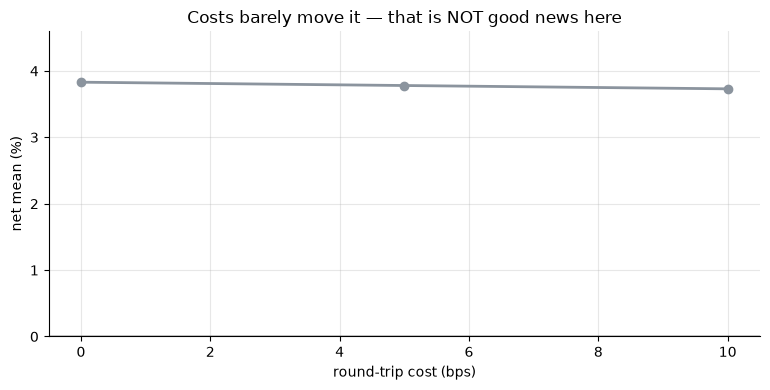

Cost is irrelevant; the problem is significance, not friction.


In [5]:
costs = [0, 5, 10]
if HAVE_REAL:
    net = [st.event_forward_returns(BARS, EVENTS, horizon=20, cost_bps=c)['ret_net'].mean()*100 for c in costs]
else:
    net = [3.83, 3.78, 3.73]
fig, ax = plt.subplots(figsize=(7.8, 4.0))
ax.plot(costs, net, 'o-', c=GREY, lw=2)
ax.axhline(0, c='k', lw=1); ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (%)')
ax.set_ylim(0, max(net)*1.2); ax.set_title('Costs barely move it — that is NOT good news here')
plt.tight_layout(); plt.show()
print('Cost is irrelevant; the problem is significance, not friction.')

> 💡 In plain words: when a strategy is cost-insensitive *and* statistically empty, the lesson is that there was never anything to trade — costs only matter once you have an edge to erode.

## 7 · Going further — the engine is a faithful detector

Is the null result a broken test, or a true absence of signal? Plant a real post-event bounce in a synthetic tape and confirm the *same* engine recovers it — and finds nothing when nothing is planted.

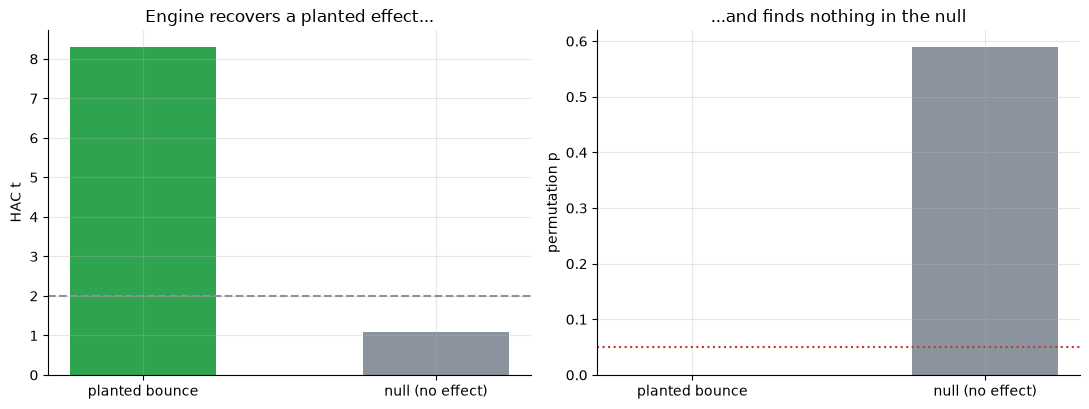

            tape  n  mean%  HAC_t  excess%  perm_p
  planted bounce 40 6.3063 8.3075   5.8779    0.00
null (no effect) 40 0.9861 1.0777   0.4334    0.59


In [6]:
# positive control vs null, on deterministic synthetic tapes
out = []
for eff, lab, sd in [(0.002,'planted bounce',311), (0.0,'null (no effect)',314)]:
    b, ev, _ = data.synthetic_daily(event_effect=eff, n_events=40, seed=sd)
    led = st.event_forward_returns(b, ev, horizon=20)
    nul = data.synthetic_null_events(b, n_events=400, window=20, seed=sd+1)
    nret = st.all_horizon_returns(b, st.snap_to_sessions(b, nul), 20)
    s = st.summarize(led['ret_gross'].to_numpy())
    obs, p = st.permutation_pvalue(led['ret_gross'].to_numpy(), nret, n_perm=20000)
    out.append((lab, s['n'], s['mean']*100, s['tstat'], obs*100, p))
dfc = pd.DataFrame(out, columns=['tape','n','mean%','HAC_t','excess%','perm_p'])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
a1.bar(dfc['tape'], dfc['HAC_t'], color=[GREEN, GREY], width=.5); a1.axhline(2, ls='--', c=GREY)
a1.set_ylabel('HAC t'); a1.set_title('Engine recovers a planted effect...')
a2.bar(dfc['tape'], dfc['perm_p'], color=[GREEN, GREY], width=.5); a2.axhline(0.05, ls=':', c=RED)
a2.set_ylabel('permutation p'); a2.set_title('...and finds nothing in the null')
plt.tight_layout(); plt.show()
print(dfc.round(4).to_string(index=False))

The harness banks the planted bounce (HAC *t* +8.3, permutation *p* < 0.0001) and correctly finds nothing in the null (*p* = 0.59). Across 20 seeds the null's excess-over-random averages ~0 and ~5% of seeds give p < 0.05 — the nominal false-positive rate. So the real-data null is a statement about **the market**: five shutdowns simply don't carry enough signal to clear the right benchmark.

For the same illusion in other guises, see [Study 287 — Easter-Effect](../../287-easter-effect/) and [Study 301 — Triple-RSI](../../301-triple-rsi/).